In [1]:
# Import libraries.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [2]:
# Import data.
sr = pd.read_csv('spirituality_and_religion.csv')

# View data.
sr

,Country,Religious,There is definitely/probably life after death,Parts of nature can have spirits or spiritual energies,Pray at least daily,"Consult a fortune teller, horoscope or other way to see the future"
0,Ghana,98,74.0,87.0,73.0,16.0
1,India,99,43.0,79.0,71.0,45.0
2,Chile,66,67.0,74.0,41.0,14.0
3,South Africa,86,59.0,74.0,63.0,47.0
4,Philippines,99,78.0,73.0,79.0,22.0
5,Thailand,100,50.0,73.0,31.0,29.0
6,Colombia,77,67.0,70.0,71.0,11.0
7,Turkey,95,84.0,65.0,63.0,7.0
8,Peru,88,68.0,65.0,58.0,16.0
9,Argentina,76,65.0,65.0,39.0,14.0


In [3]:
# Strip spaces.
sr.columns = sr.columns.str.strip()

In [4]:
# Strip decimal places.
for col in sr.select_dtypes(include=['float']).columns:
    sr[col] = sr[col].round(0).astype("Int64")

In [5]:
# Replace all nulls with zero.
sr = sr.fillna(0)

In [6]:
# Create a function to create a circular bar chart.
def plot_circular_bar_chart(df, category_col, value_col, inner_radius=30,
                            start_hex='#08306b', end_hex='#c6dbef'):
    """
    Circular bar chart with:
    - Blank centre
    - Italic and bold country labels
    - Percent values shown inside the bars
    - Clockwise order, largest at 12 o'clock
    - Uses Palatino Linotype font
    - Custom gradient from start_hex (dark/high) to end_hex (light/low)
    """

    df = df[df[value_col].notna() & (df[value_col] != 0)]
    df = df.sort_values(by=value_col, ascending=False).reset_index(drop=True)

    labels = df[category_col].tolist()
    values = df[value_col].tolist()
    N = len(values)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles = (np.pi / 2 - angles) % (2 * np.pi)
    width = 2 * np.pi / N * 0.8

    norm = Normalize(vmin=min(values), vmax=max(values))
    cmap = LinearSegmentedColormap.from_list("custom_cmap", [end_hex, start_hex])
    colors = [cmap(norm(v)) for v in values]

    fig, ax = plt.subplots(figsize=(18, 18), subplot_kw={'polar': True})
    bars = ax.bar(angles, values, width=width, bottom=inner_radius,
                  color=colors, edgecolor='black', linewidth=1.2)

    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_xticklabels([])

    label_radius = np.array(values) + inner_radius + 4
    for angle, radius, label in zip(angles, label_radius, labels):
        rotation = np.degrees(angle)
        if np.isclose(rotation, 90, atol=1):
            alignment = "left"
            rotation = 90
        else:
            if 90 < rotation < 270:
                alignment = "right"
                rotation += 180
            else:
                alignment = "left"

        ax.text(angle, radius, label, size=20,
                style='italic', fontweight='bold',
                horizontalalignment=alignment,
                verticalalignment='center',
                rotation=rotation,
                rotation_mode='anchor',
                fontname='Palatino Linotype')

    for angle, value in zip(angles, values):
        ax.text(angle, inner_radius + value - 6, f"{int(value)}%",
                ha='center', va='center',
                fontsize=14, color='black',
                fontweight='bold',
                fontname='Palatino Linotype')

    # Save and show the plot.
    filename = f"{value_col.lower().replace(' ', '_').replace('/', '')}.png"
    plt.savefig(filename, transparent=True, dpi=300)
    plt.show()

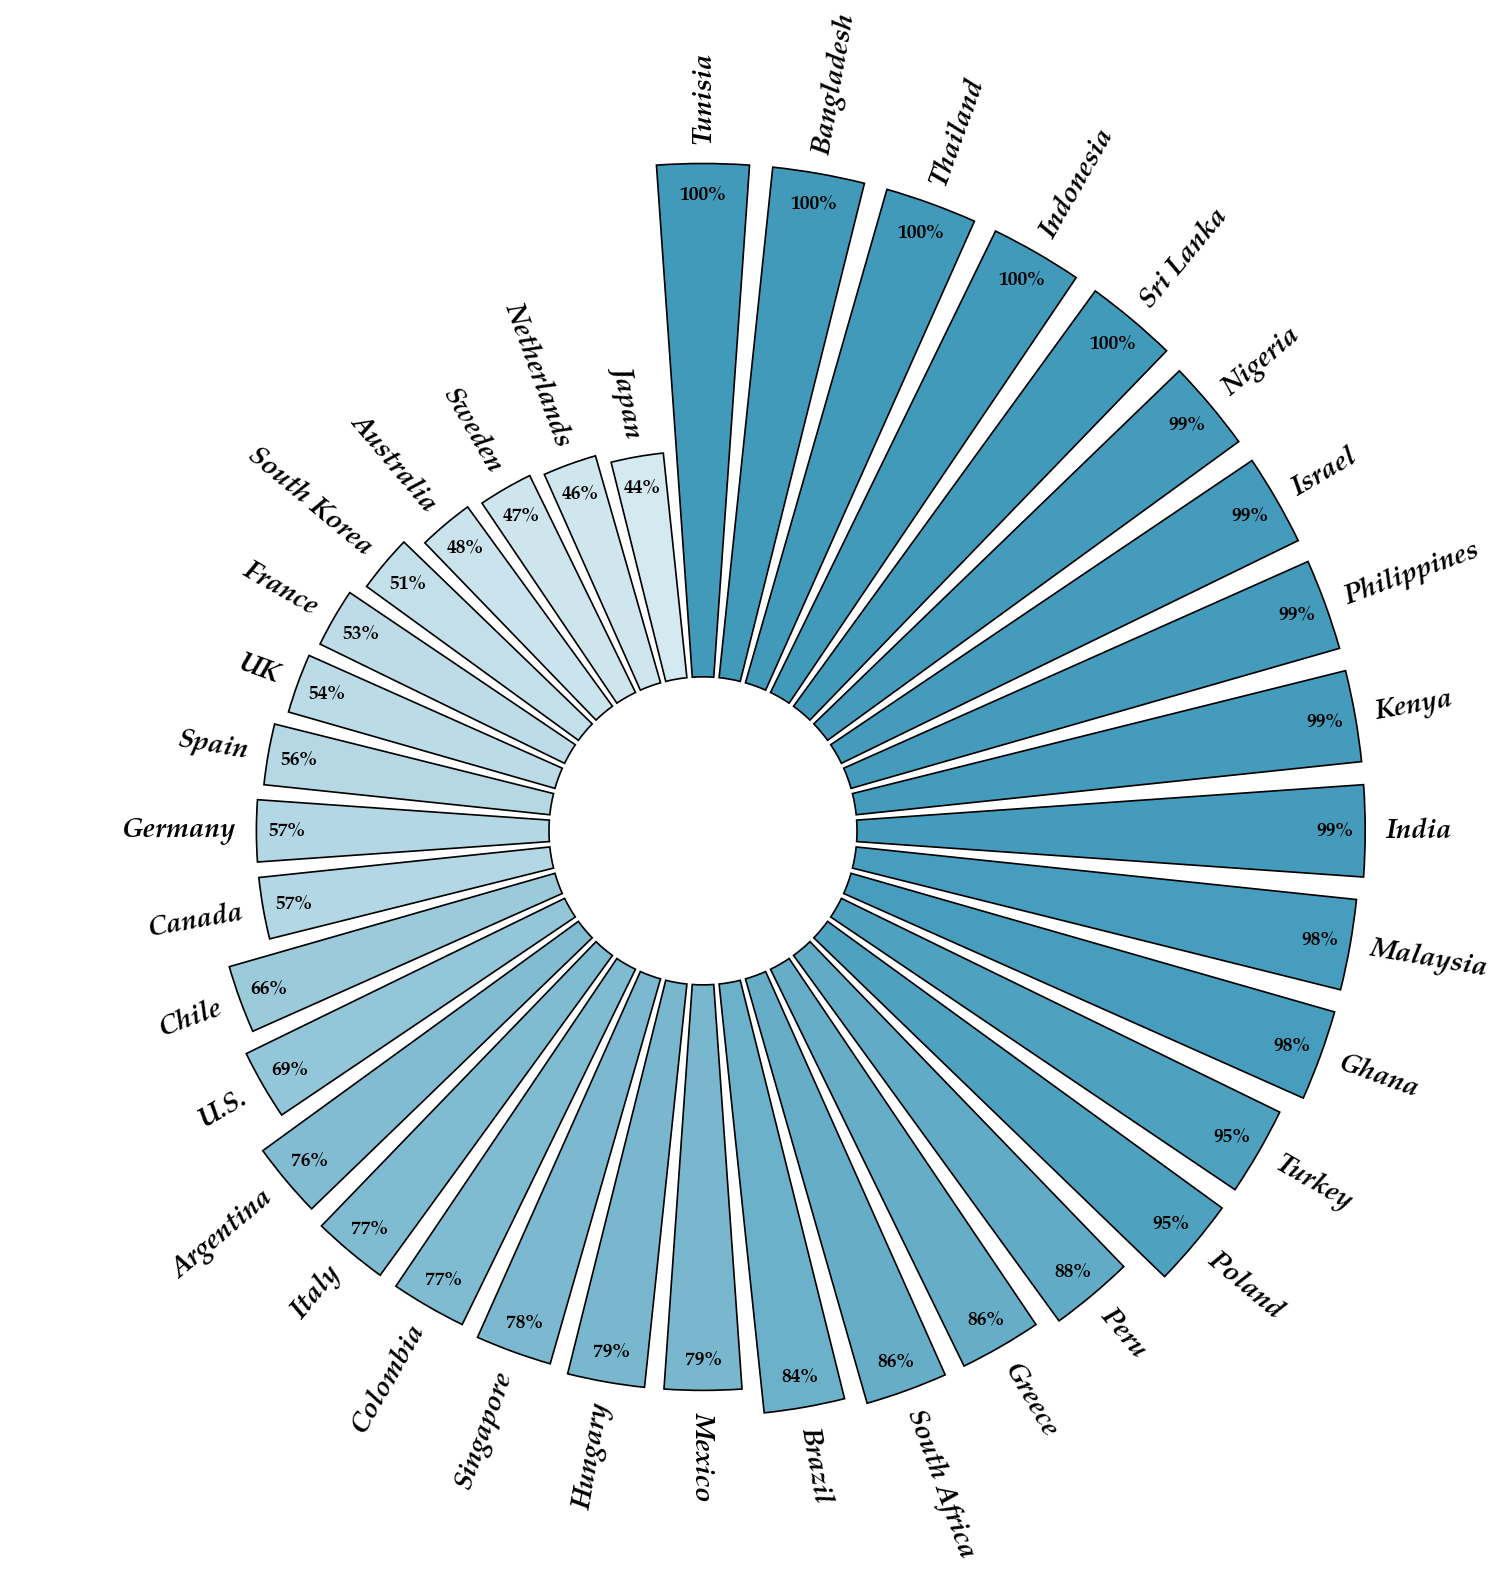

In [7]:
# Call the function for "Religious".
plot_circular_bar_chart(sr, "Country", "Religious", inner_radius=30, 
                        start_hex='#429abb', end_hex='#d5e9f0')

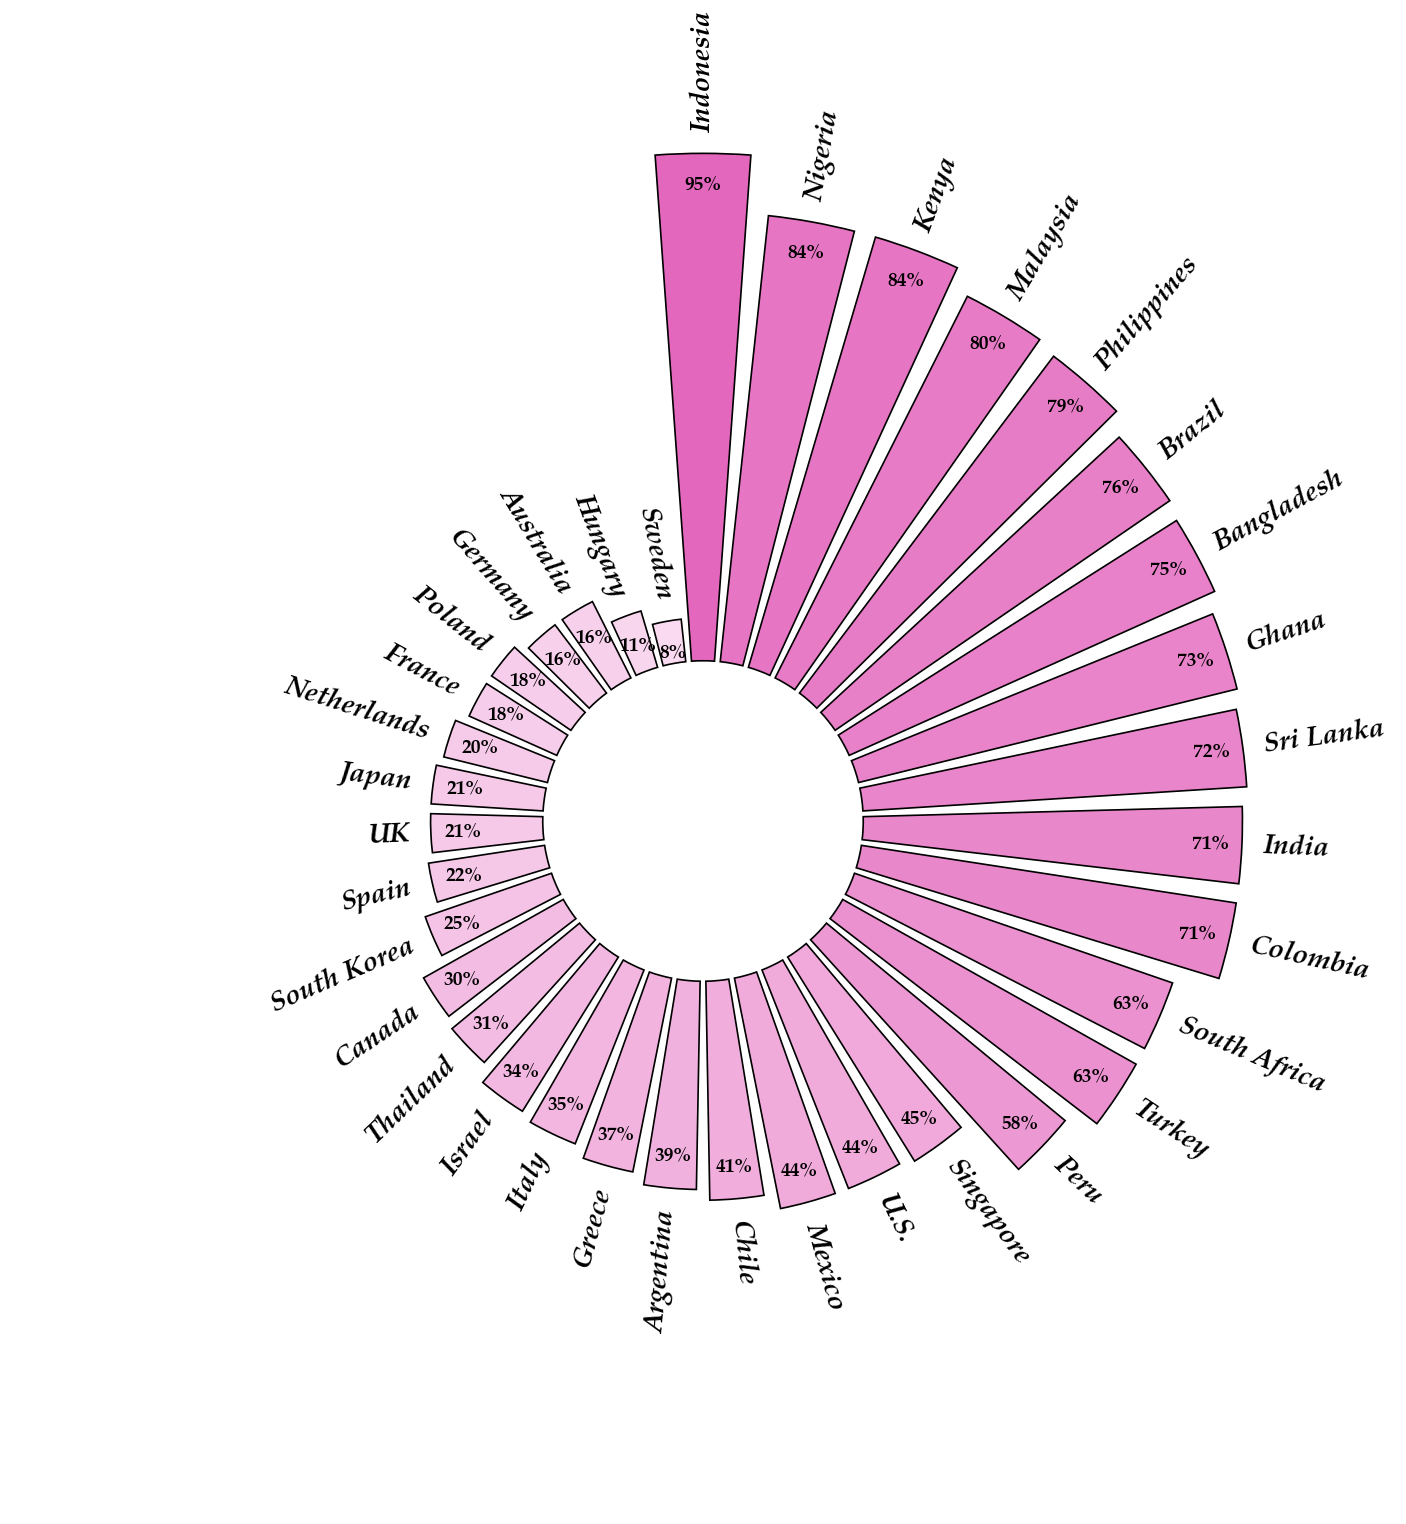

In [8]:
# Call the function for "Pray at least daily."
plot_circular_bar_chart(sr, "Country", "Pray at least daily", inner_radius=30, 
                        start_hex='#E367BD', end_hex='#F9DAF0')

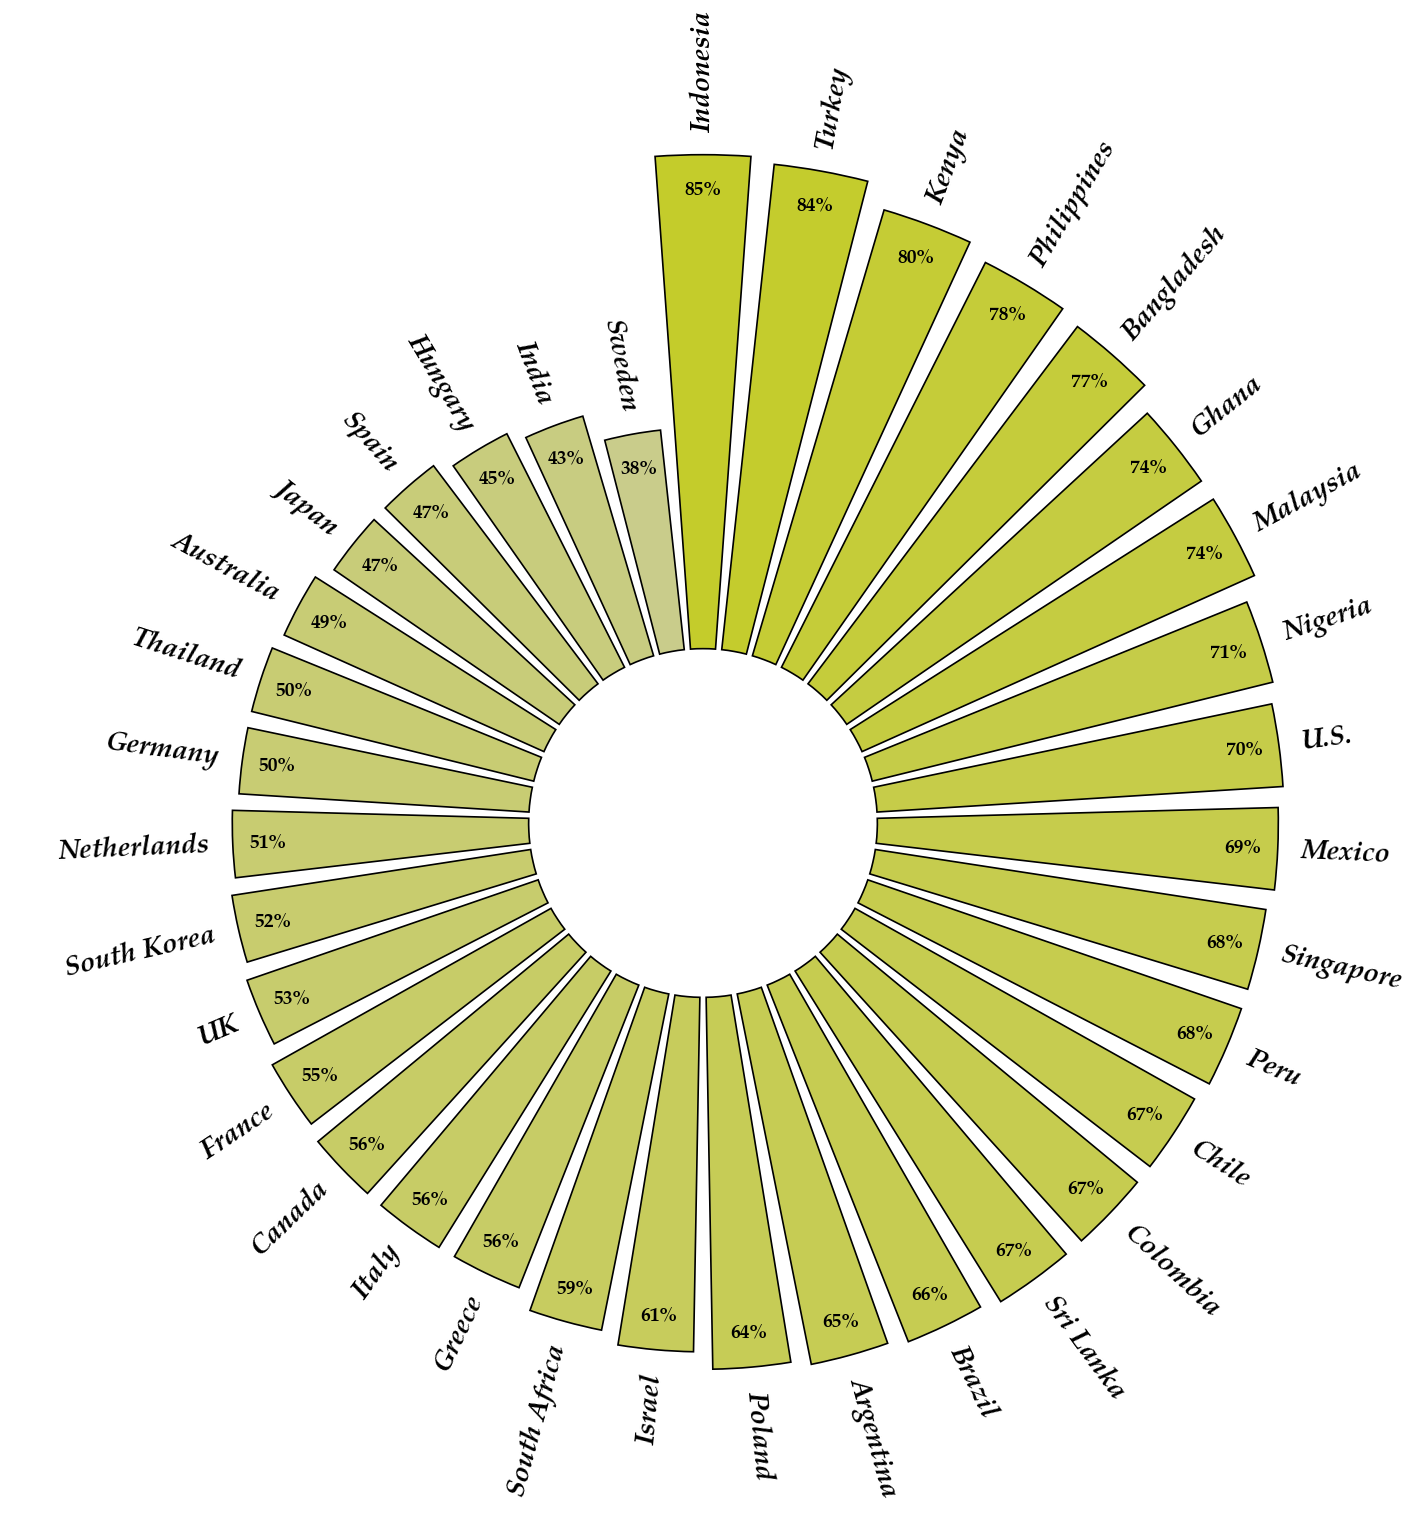

In [9]:
# Call the function for "Afterlife".
plot_circular_bar_chart(sr, "Country", "There is definitely/probably life after death", inner_radius=30, 
                        start_hex='#C4CC2B', end_hex='#C9CC8B')

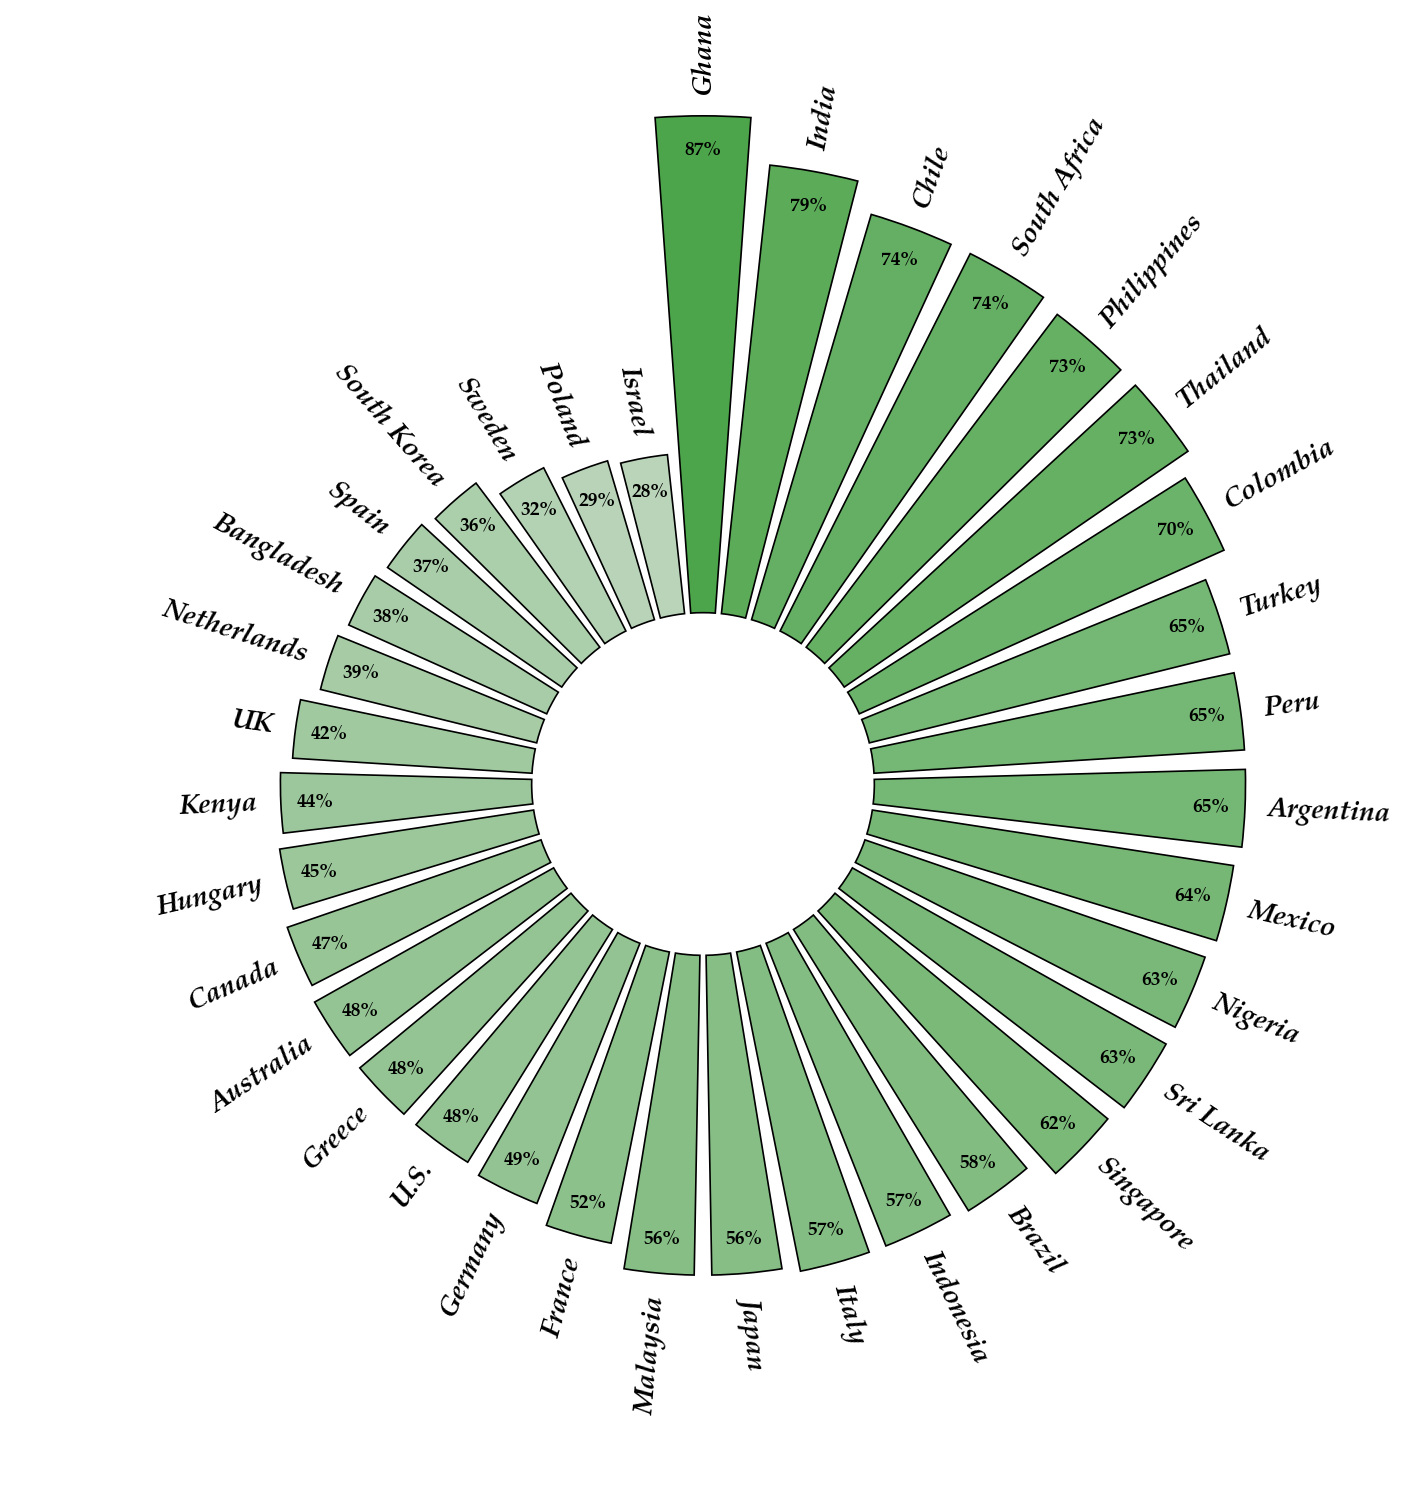

In [10]:
# Call the function for "Nature".
plot_circular_bar_chart(sr, "Country", "Parts of nature can have spirits or spiritual energies", 
                        inner_radius=30, start_hex='#4CA54A', end_hex='#BAD4BA')

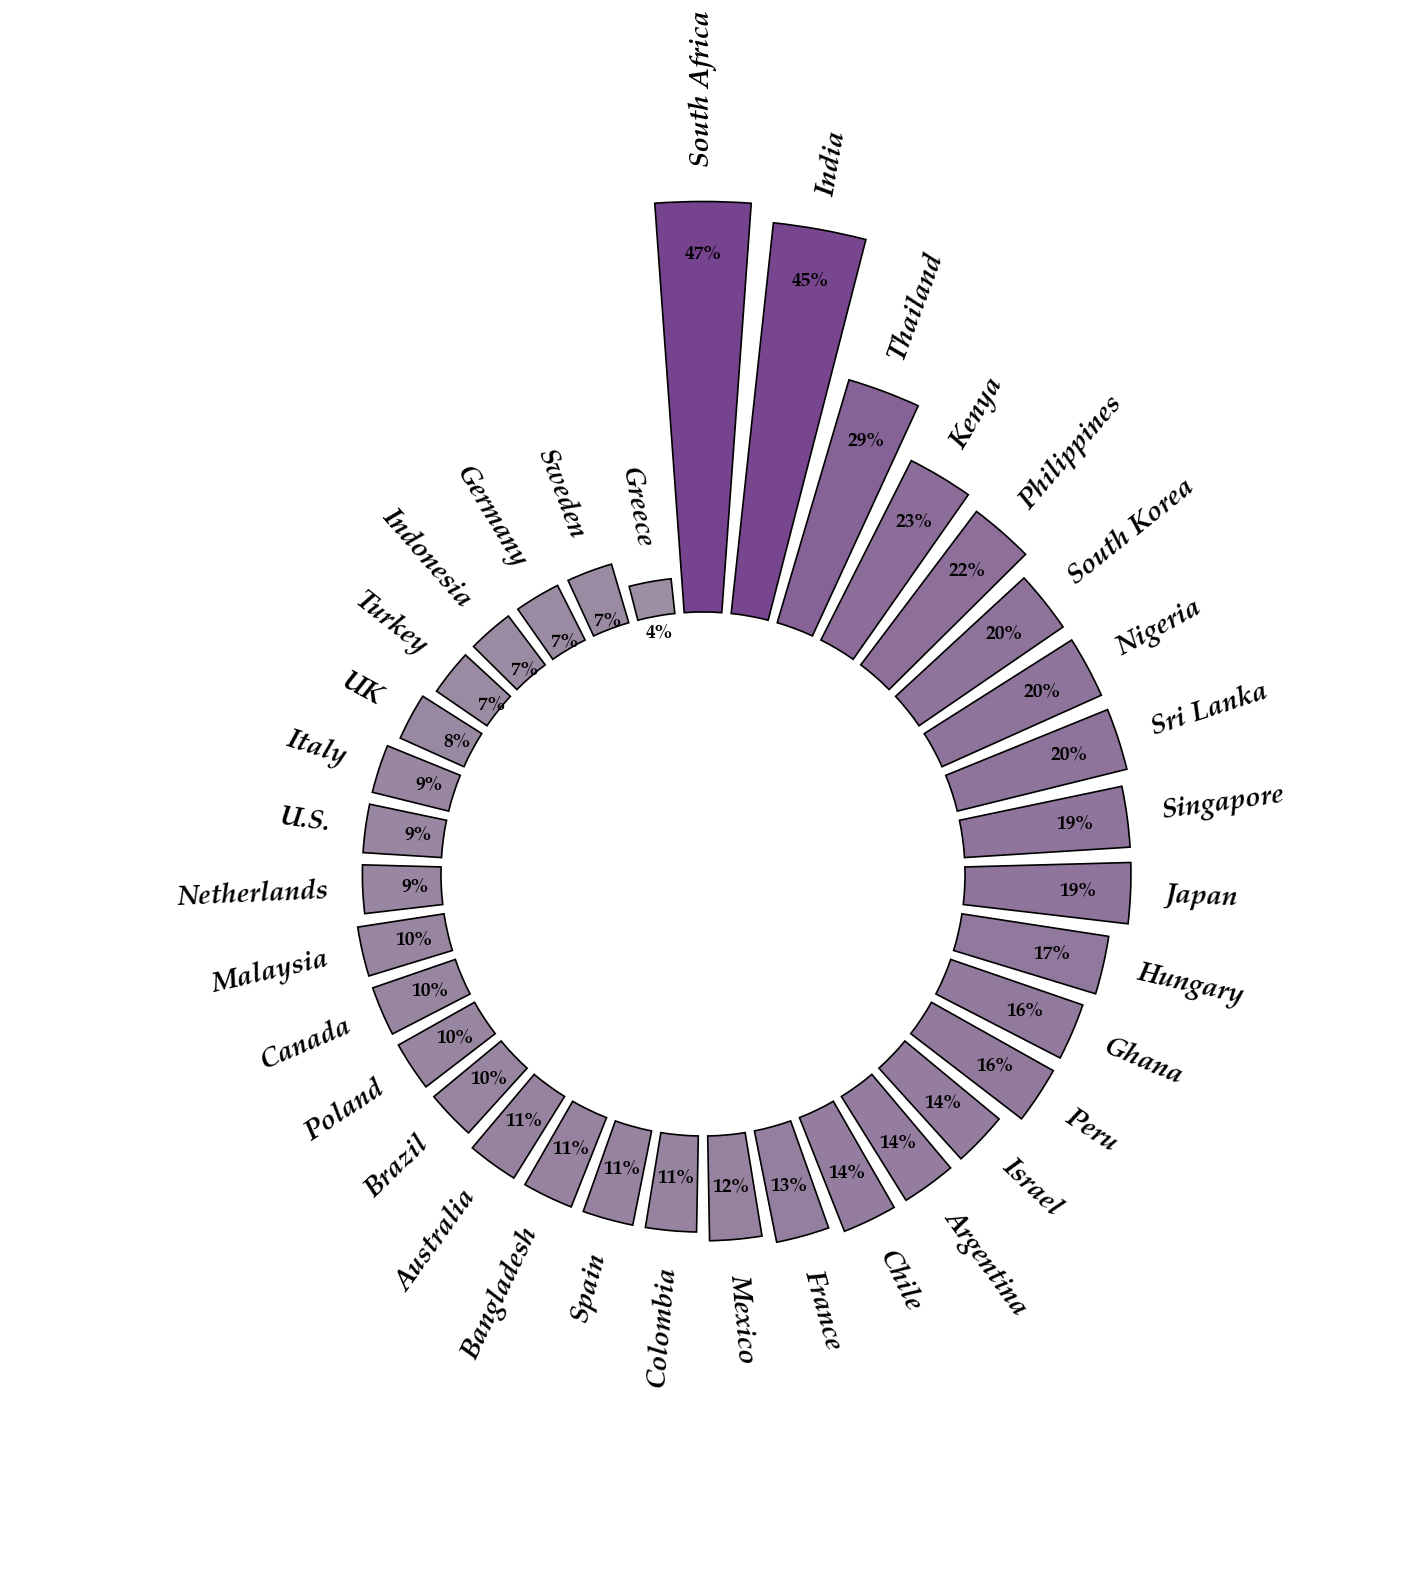

In [11]:
# Call the function for "Fortune telling".
plot_circular_bar_chart(sr, "Country", "Consult a fortune teller, horoscope or other way to see the future", 
                        inner_radius=30, start_hex='#76438E', end_hex='#9D8FA3')